# 07 — Training Ablations

## E2 — Label Smoothing (ε = 0.1)

Trains the **same** tiny Transformer from scratch, changing only the loss to
`CrossEntropyLoss(label_smoothing=0.1)`. Everything else (architecture, data, optimizer,
seed) matches the original full model, so the comparison is fair.

**Why:** the original greedy model produces degenerate **repetition in ~50% of outputs**
(notebook 05). Label smoothing discourages over-confident next-token distributions, which
often reduces repetition and improves generalization in low-resource NMT.

Original checkpoints/results are **not** touched; E2 is saved separately under
`outputs/checkpoints/e2_label_smoothing_0p1/`.

## Setup and CPU configuration
Using the benchmarked settings from notebook 04: 8 torch threads, 0 DataLoader workers.

In [1]:
import os
CPU_CORES = os.cpu_count() or 1
TORCH_THREADS = min(8, CPU_CORES)     # benchmarked sweet spot (notebook 04)
DATALOADER_WORKERS = 0                  # benchmarked: workers give no gain + hang on Windows
os.environ.setdefault("OMP_NUM_THREADS", str(TORCH_THREADS))
os.environ.setdefault("MKL_NUM_THREADS", str(TORCH_THREADS))

import math, random, time, shutil
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import sacrebleu, sentencepiece as spm
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from IPython.display import display

torch.set_num_threads(TORCH_THREADS)
print(f"CPU cores={CPU_CORES} | torch threads={torch.get_num_threads()} | dataloader workers={DATALOADER_WORKERS}")

CPU cores=28 | torch threads=8 | dataloader workers=0


## Configuration
Same as the original run except `label_smoothing = 0.1`.

In [2]:
SEED = 42
MAX_LEN = 80
BATCH_SIZE = 32
MAX_EPOCHS = 40
ARCH = dict(d_model=128, nhead=4, num_encoder_layers=2, num_decoder_layers=2,
            dim_feedforward=512, dropout=0.1)
TRAIN = dict(learning_rate=3e-4, weight_decay=0.0, clip_grad_norm=1.0,
             label_smoothing=0.1, early_stopping_patience=10)
EXPERIMENT_ID = "E2_label_smoothing_0p1"

RUN_TRAINING = True
AUTO_RESUME = True
FORCE_RESTART = False
SAVE_EVERY_EPOCH = True

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cpu")
display(pd.DataFrame([{**ARCH, **TRAIN, 'max_epochs': MAX_EPOCHS, 'batch_size': BATCH_SIZE,
                       'seed': SEED, 'experiment_id': EXPERIMENT_ID}]).T.rename(columns={0: 'value'}))

,value
d_model,128
nhead,4
num_encoder_layers,2
num_decoder_layers,2
dim_feedforward,512
dropout,0.1
learning_rate,0.0003
weight_decay,0.0
clip_grad_norm,1.0
label_smoothing,0.1


## Paths
E2 checkpoints live in their own folder; the original `best_full_model.pt` is never overwritten.

In [3]:
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TOK = ROOT / "Data" / "tokenized"; VOC = ROOT / "Data" / "vocab"
TABLES = ROOT / "outputs" / "tables"; FIGURES = ROOT / "outputs" / "figures"
EXAMPLES = ROOT / "outputs" / "examples"
E2_DIR = ROOT / "outputs" / "checkpoints" / "e2_label_smoothing_0p1"
for p in (TABLES, FIGURES, EXAMPLES, E2_DIR):
    p.mkdir(parents=True, exist_ok=True)
E2_BEST = E2_DIR / "best.pt"; E2_LATEST = E2_DIR / "latest.pt"
E2_LOG = TABLES / "e2_training_log.csv"
print("E2 checkpoint dir:", E2_DIR)

E2 checkpoint dir: D:\Ahmed Sherif\Digilians\Deep Learning\Project\Low-Resource Machine Translation with Tiny Transformers\outputs\checkpoints\e2_label_smoothing_0p1


## Vocabulary, dataset, dataloaders
Same SentencePiece files and same filtered data as the original run.

In [4]:
def load_vocab(path):
    tokens = [l.rstrip("\n").split("\t", 1)[0] for l in open(path, encoding="utf-8") if l.strip()]
    return tokens, {t: i for i, t in enumerate(tokens)}, {i: t for i, t in enumerate(tokens)}

def encode_pieces(pieces, stoi, add_bos=True, add_eos=True):
    ids = [stoi.get(p, stoi["<unk>"]) for p in pieces]
    return ([stoi["<s>"]] if add_bos else []) + ids + ([stoi["</s>"]] if add_eos else [])

def decode_ids(ids, itos, eos):
    out = []
    for i in ids:
        if i == eos: break
        if itos[i] not in ("<pad>", "<s>"): out.append(itos[i])
    return out

src_tokens, src_stoi, src_itos = load_vocab(VOC / "sp_ar.vocab")
tgt_tokens, tgt_stoi, tgt_itos = load_vocab(VOC / "sp_en.vocab")
PAD, BOS, EOS = src_stoi["<pad>"], tgt_stoi["<s>"], tgt_stoi["</s>"]
sp_en = spm.SentencePieceProcessor(model_file=str(VOC / "sp_en.model"))
sp_ar = spm.SentencePieceProcessor(model_file=str(VOC / "sp_ar.model"))

In [5]:
class TranslationDataset(Dataset):
    def __init__(self, src_path, tgt_path, max_len):
        s = Path(src_path).read_text(encoding="utf-8").splitlines()
        t = Path(tgt_path).read_text(encoding="utf-8").splitlines()
        self.examples = []
        for a, b in zip(s, t):
            ap, bp = a.split(), b.split()
            if len(ap) > max_len or len(bp) > max_len: continue
            self.examples.append((encode_pieces(ap, src_stoi), encode_pieces(bp, tgt_stoi)))
        self.total = len(s)
    def __len__(self): return len(self.examples)
    def __getitem__(self, i): return self.examples[i]

def collate(batch, pad=PAD):
    src, tgt = zip(*batch)
    sw, tw = max(len(x) for x in src), max(len(x) for x in tgt)
    sb = torch.full((len(batch), sw), pad, dtype=torch.long)
    tb = torch.full((len(batch), tw), pad, dtype=torch.long)
    for r, (a, b) in enumerate(batch):
        sb[r, :len(a)] = torch.tensor(a); tb[r, :len(b)] = torch.tensor(b)
    return {"src": sb, "tgt_input": tb[:, :-1], "tgt_output": tb[:, 1:]}

train_ds = TranslationDataset(TOK / "train.ar.bpe", TOK / "train.en.bpe", MAX_LEN)
val_ds = TranslationDataset(TOK / "validation.ar.bpe", TOK / "validation.en.bpe", MAX_LEN)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=DATALOADER_WORKERS, collate_fn=collate)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=DATALOADER_WORKERS, collate_fn=collate)
print(f"train kept={len(train_ds)}/{train_ds.total} | val kept={len(val_ds)}/{val_ds.total}")

train kept=49441/50000 | val kept=869/888


## Model architecture
Identical to `src/model.py` / notebook 04 (so the comparison isolates the loss change).

In [6]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=512):
        super().__init__(); self.dropout = nn.Dropout(dropout)
        pos = torch.arange(max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(pos * div); pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x): return self.dropout(x + self.pe[:, : x.size(1)])

class TinyTransformerMT(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, src_pad, tgt_pad, d_model=128, nhead=4,
                 num_encoder_layers=2, num_decoder_layers=2, dim_feedforward=512, dropout=0.1, max_len=256):
        super().__init__()
        self.src_pad_id, self.tgt_pad_id, self.d_model = src_pad, tgt_pad, d_model
        self.src_embedding = nn.Embedding(src_vocab, d_model, padding_idx=src_pad)
        self.tgt_embedding = nn.Embedding(tgt_vocab, d_model, padding_idx=tgt_pad)
        self.positional_encoding = PositionalEncoding(d_model, dropout, max_len=max_len)
        self.transformer = nn.Transformer(d_model=d_model, nhead=nhead,
            num_encoder_layers=num_encoder_layers, num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True)
        self.output_projection = nn.Linear(d_model, tgt_vocab)
    def forward(self, src, tgt_input):
        L = tgt_input.size(1)
        tgt_mask = torch.triu(torch.ones(L, L, dtype=torch.bool, device=tgt_input.device), diagonal=1)
        skp = src.eq(self.src_pad_id); tkp = tgt_input.eq(self.tgt_pad_id)
        se = self.positional_encoding(self.src_embedding(src) * math.sqrt(self.d_model))
        te = self.positional_encoding(self.tgt_embedding(tgt_input) * math.sqrt(self.d_model))
        h = self.transformer(se, te, tgt_mask=tgt_mask, src_key_padding_mask=skp,
                             tgt_key_padding_mask=tkp, memory_key_padding_mask=skp)
        return self.output_projection(h)

torch.manual_seed(SEED)   # same init as the original run
model = TinyTransformerMT(len(src_tokens), len(tgt_tokens), PAD, PAD, max_len=MAX_LEN + 2, **ARCH).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"trainable parameters: {n_params:,}")

trainable parameters: 4,006,208


## Loss and optimizer
**The one change vs. the original run:** `label_smoothing=0.1` (still ignoring PAD targets).

In [7]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD, label_smoothing=TRAIN["label_smoothing"])
optimizer = torch.optim.Adam(model.parameters(), lr=TRAIN["learning_rate"], weight_decay=TRAIN["weight_decay"])
print(f"loss: CrossEntropyLoss(ignore_index={PAD}, label_smoothing={TRAIN['label_smoothing']})")

loss: CrossEntropyLoss(ignore_index=0, label_smoothing=0.1)


## Train / validate one epoch

In [8]:
def run_epoch(loader, train):
    model.train(train)
    total_loss, total_tokens = 0.0, 0
    for batch in loader:
        src, ti, to = batch["src"], batch["tgt_input"], batch["tgt_output"]
        with torch.set_grad_enabled(train):
            logits = model(src, ti)
            loss = criterion(logits.reshape(-1, logits.size(-1)), to.reshape(-1))
            if train:
                optimizer.zero_grad(set_to_none=True); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), TRAIN["clip_grad_norm"]); optimizer.step()
        ntok = to.ne(PAD).sum().item()
        total_loss += loss.item() * ntok; total_tokens += ntok
    return total_loss / max(1, total_tokens)

## Checkpoint-safe training
Resumes from `latest.pt`; skips if E2 already trained to `MAX_EPOCHS`. Saves every epoch to the
E2 folder and appends to `e2_training_log.csv`. The original checkpoints are never written here.

In [9]:
def save_ckpt(path, epoch, best_val, history):
    torch.save({"model_state_dict": model.state_dict(), "optimizer_state_dict": optimizer.state_dict(),
                "epoch": epoch, "best_val_loss": best_val, "history": history,
                "config": {**ARCH, **TRAIN, "experiment_id": EXPERIMENT_ID}, "seed": SEED}, path)

if FORCE_RESTART and any(E2_DIR.iterdir()):
    arch = ROOT / "outputs" / "archive" / f"e2_{time.strftime('%Y%m%d_%H%M%S')}"
    arch.mkdir(parents=True, exist_ok=True)
    for f in E2_DIR.iterdir(): shutil.move(str(f), str(arch / f.name))
    if E2_LOG.exists(): shutil.move(str(E2_LOG), str(arch / E2_LOG.name))
    print("archived old E2 outputs to", arch)

start_epoch, best_val, history = 1, float("inf"), []
if AUTO_RESUME and E2_LATEST.exists() and not FORCE_RESTART:
    ck = torch.load(E2_LATEST, map_location=device, weights_only=False)
    model.load_state_dict(ck["model_state_dict"]); optimizer.load_state_dict(ck["optimizer_state_dict"])
    start_epoch = ck["epoch"] + 1; best_val = ck["best_val_loss"]; history = ck.get("history", [])
    print(f"resuming E2 from epoch {ck['epoch']} (best_val={best_val:.4f})")

if E2_BEST.exists() and (start_epoch - 1) >= MAX_EPOCHS and not FORCE_RESTART:
    RUN_TRAINING = False
    ck = torch.load(E2_BEST, map_location=device, weights_only=False)
    model.load_state_dict(ck["model_state_dict"])
    print(f"E2 already trained to {MAX_EPOCHS} epochs; loaded best (epoch {ck['epoch']}, val {ck['best_val_loss']:.4f}).")

In [10]:
if RUN_TRAINING:
    for epoch in range(start_epoch, MAX_EPOCHS + 1):
        t0 = time.time()
        tr = run_epoch(train_loader, train=True)
        va = run_epoch(val_loader, train=False)
        improved = va < best_val
        if improved: best_val = va
        et = time.time() - t0
        history.append({"experiment_id": EXPERIMENT_ID, "epoch": epoch, "train_loss": tr,
                        "val_loss": va, "best_val_loss": best_val, "epoch_time_s": round(et, 1)})
        pd.DataFrame(history).to_csv(E2_LOG, index=False)
        save_ckpt(E2_LATEST, epoch, best_val, history)
        if SAVE_EVERY_EPOCH: save_ckpt(E2_DIR / f"epoch_{epoch:03d}.pt", epoch, best_val, history)
        if improved: save_ckpt(E2_BEST, epoch, best_val, history)
        print(f"epoch {epoch}/{MAX_EPOCHS} | train={tr:.4f} val={va:.4f} best={best_val:.4f} "
              f"| {et:.0f}s | saved {E2_LATEST.name}{' + best' if improved else ''}", flush=True)
    ck = torch.load(E2_BEST, map_location=device, weights_only=False)
    model.load_state_dict(ck["model_state_dict"])
    print(f"loaded best E2 checkpoint (epoch {ck['epoch']}, val {ck['best_val_loss']:.4f}) for evaluation")

D:\Ahmed Sherif\Digilians\Deep Learning\Project\Low-Resource Machine Translation with Tiny Transformers\.venv\Lib\site-packages\torch\nn\modules\transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


epoch 1/40 | train=6.1547 val=5.8530 best=5.8530 | 313s | saved latest.pt + best


epoch 2/40 | train=5.6784 val=5.5971 best=5.5971 | 294s | saved latest.pt + best


epoch 3/40 | train=5.4904 val=5.4541 best=5.4541 | 284s | saved latest.pt + best


epoch 4/40 | train=5.3557 val=5.3415 best=5.3415 | 291s | saved latest.pt + best


...

epoch 37/40 | train=4.3831 val=4.7160 best=4.7160 | 281s | saved latest.pt + best


epoch 38/40 | train=4.3724 val=4.7119 best=4.7119 | 284s | saved latest.pt + best


epoch 39/40 | train=4.3624 val=4.7029 best=4.7029 | 280s | saved latest.pt + best


epoch 40/40 | train=4.3542 val=4.7040 best=4.7029 | 286s | saved latest.pt


loaded best E2 checkpoint (epoch 39, val 4.7029) for evaluation


## Training log and loss curve

,experiment_id,epoch,train_loss,val_loss,best_val_loss,epoch_time_s
34,E2_label_smoothing_0p1,35,4.403719,4.726756,4.726756,289.5
35,E2_label_smoothing_0p1,36,4.394198,4.718571,4.718571,281.6
36,E2_label_smoothing_0p1,37,4.383116,4.715988,4.715988,281.0
37,E2_label_smoothing_0p1,38,4.372379,4.711934,4.711934,283.8
38,E2_label_smoothing_0p1,39,4.362388,4.702917,4.702917,279.8
39,E2_label_smoothing_0p1,40,4.354159,4.703973,4.702917,286.2


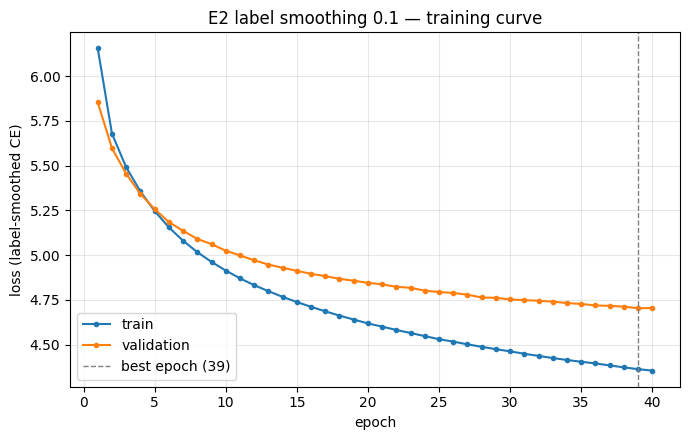

In [11]:
log = pd.read_csv(E2_LOG)
best_epoch = int(log.loc[log["val_loss"].idxmin(), "epoch"])
display(log.tail(6))
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(log.epoch, log.train_loss, marker="o", ms=3, label="train")
ax.plot(log.epoch, log.val_loss, marker="o", ms=3, label="validation")
ax.axvline(best_epoch, color="grey", ls="--", lw=1, label=f"best epoch ({best_epoch})")
ax.set_xlabel("epoch"); ax.set_ylabel("loss (label-smoothed CE)")
ax.set_title("E2 label smoothing 0.1 — training curve"); ax.grid(alpha=0.3); ax.legend()
fig.tight_layout(); fig.savefig(FIGURES / "e2_train_val_loss_curve.png", dpi=200); plt.show()

## Decoding and scoring (inline)
Greedy and beam search (beam=3, length_penalty=1.0), scored with BLEU + chrF++ on detokenized text.

In [12]:
def read_lines(p): return open(p, encoding="utf-8").read().splitlines()
pairs = [(a, b) for a, b in zip(read_lines(TOK / "test.ar.bpe"), read_lines(TOK / "test.en.bpe"))
         if len(a.split()) <= MAX_LEN and len(b.split()) <= MAX_LEN]
test_ar = [a for a, b in pairs]
reference = [sp_en.decode(b.split()) for a, b in pairs]
src_text = [sp_ar.decode(a.split()) for a, b in pairs]
print(f"test pairs kept: {len(pairs)}")

def score(hyp, ref):
    return (round(sacrebleu.corpus_bleu(hyp, [ref]).score, 4),
            round(sacrebleu.corpus_chrf(hyp, [ref], word_order=2).score, 4))

def encode_batch(lines):
    ids = [encode_pieces(l.split(), src_stoi) for l in lines]
    w = max(len(x) for x in ids)
    b = torch.full((len(ids), w), PAD, dtype=torch.long)
    for r, s in enumerate(ids): b[r, :len(s)] = torch.tensor(s)
    return b

test pairs kept: 8491


In [13]:
@torch.no_grad()
def greedy(lines, batch_size=32):
    model.eval(); out = []
    for i in range(0, len(lines), batch_size):
        src = encode_batch(lines[i:i + batch_size])
        ys = torch.full((src.size(0), 1), BOS, dtype=torch.long)
        done = torch.zeros(src.size(0), dtype=torch.bool)
        for _ in range(MAX_LEN):
            nxt = model(src, ys)[:, -1].argmax(-1).masked_fill(done, PAD)
            ys = torch.cat([ys, nxt.unsqueeze(1)], 1); done |= nxt.eq(EOS)
            if done.all(): break
        for row in ys.tolist(): out.append(sp_en.decode(decode_ids(row, tgt_itos, EOS)))
    return out

@torch.no_grad()
def beam_search(src_ids, beam=3, length_penalty=1.0):
    src = torch.tensor([src_ids]); skp = src.eq(PAD)
    se = model.positional_encoding(model.src_embedding(src) * math.sqrt(model.d_model))
    memory = model.transformer.encoder(se, src_key_padding_mask=skp).expand(beam, -1, -1).contiguous()
    mkp = skp.expand(beam, -1).contiguous()
    ys = torch.full((beam, 1), BOS, dtype=torch.long)
    scores = torch.full((beam,), float("-inf")); scores[0] = 0.0; finished = []
    for _ in range(MAX_LEN):
        L = ys.size(1)
        cm = torch.triu(torch.ones(L, L, dtype=torch.bool), diagonal=1)
        te = model.positional_encoding(model.tgt_embedding(ys) * math.sqrt(model.d_model))
        dec = model.transformer.decoder(te, memory, tgt_mask=cm, memory_key_padding_mask=mkp)
        logp = torch.log_softmax(model.output_projection(dec[:, -1]), dim=-1)
        V = logp.size(-1)
        ts, ti = (scores.unsqueeze(1) + logp).view(-1).topk(beam)
        ys = torch.cat([ys[torch.div(ti, V, rounding_mode="floor")], (ti % V).unsqueeze(1)], 1)
        scores = ts.clone()
        for b in range(beam):
            if (ti[b] % V).item() == EOS:
                finished.append((scores[b].item() / max(1, ys.size(1) - 1) ** length_penalty, ys[b].tolist()))
                scores[b] = float("-inf")
        if len(finished) >= beam or torch.isinf(scores).all(): break
    if not finished:
        b = int(scores.argmax()); finished.append((scores[b].item(), ys[b].tolist()))
    return max(finished, key=lambda x: x[0])[1]

def beam_translate(lines, beam=3, lp=1.0):
    model.eval()
    return [sp_en.decode(decode_ids(beam_search(encode_pieces(l.split(), src_stoi), beam, lp), tgt_itos, EOS))
            for l in lines]

## E2 evaluation — greedy (1,000 subset, then full test)

In [14]:
t = time.time(); e2_greedy_1k = greedy(test_ar[:1000]); g1k = score(e2_greedy_1k, reference[:1000])
print(f"E2 greedy 1000: BLEU={g1k[0]} chrF++={g1k[1]} ({time.time()-t:.0f}s)")
t = time.time(); e2_greedy = greedy(test_ar); gfull = score(e2_greedy, reference)
print(f"E2 greedy FULL ({len(e2_greedy)}): BLEU={gfull[0]} chrF++={gfull[1]} ({(time.time()-t)/60:.1f} min)")
pd.DataFrame({"source_ar": src_text, "reference_en": reference, "e2_greedy": e2_greedy}).to_csv(
    EXAMPLES / "e2_predictions.csv", index=False, encoding="utf-8")

E2 greedy 1000: BLEU=6.1006 chrF++=24.8236 (42s)


E2 greedy FULL (8491): BLEU=6.0798 chrF++=25.0642 (6.0 min)


## E2 evaluation — beam search (beam=3, lp=1.0)

In [15]:
t = time.time(); e2_beam_1k = beam_translate(test_ar[:1000]); b1k = score(e2_beam_1k, reference[:1000])
print(f"E2 beam3 1000: BLEU={b1k[0]} chrF++={b1k[1]} ({(time.time()-t)/60:.1f} min)")
t = time.time(); e2_beam = beam_translate(test_ar); bfull = score(e2_beam, reference)
print(f"E2 beam3 FULL ({len(e2_beam)}): BLEU={bfull[0]} chrF++={bfull[1]} ({(time.time()-t)/60:.1f} min)")

E2 beam3 1000: BLEU=7.5562 chrF++=25.2769 (0.6 min)


E2 beam3 FULL (8491): BLEU=7.3685 chrF++=25.3485 (5.0 min)


## Comparison table
E2 vs. the dictionary baseline, the original greedy model, and the original beam-3 model (all on the full 8,491 test set).

In [16]:
prev = pd.read_csv(TABLES / "full_test_bleu_results.csv").set_index("model")
e13 = pd.read_csv(TABLES / "e13_full_test_best_beam.csv").iloc[0]
rows = [
    {"model/decoding": "Dictionary baseline", "bleu": prev.loc["dictionary_position_baseline", "bleu"],
     "chrf_pp": prev.loc["dictionary_position_baseline", "chrf_pp"], "examples": 8491},
    {"model/decoding": "Original Transformer greedy", "bleu": prev.loc["tiny_transformer_best", "bleu"],
     "chrf_pp": prev.loc["tiny_transformer_best", "chrf_pp"], "examples": 8491},
    {"model/decoding": "Original Transformer beam3 lp1.0", "bleu": e13["bleu"], "chrf_pp": e13["chrf_pp"], "examples": 8491},
    {"model/decoding": "E2 label smoothing greedy", "bleu": gfull[0], "chrf_pp": gfull[1], "examples": len(e2_greedy)},
    {"model/decoding": "E2 label smoothing beam3 lp1.0", "bleu": bfull[0], "chrf_pp": bfull[1], "examples": len(e2_beam)},
]
comparison = pd.DataFrame(rows)
comparison.to_csv(TABLES / "e2_eval_results.csv", index=False)
pd.DataFrame([{"experiment_id": EXPERIMENT_ID, "best_epoch": best_epoch,
               "best_val_loss": round(log['val_loss'].min(), 4),
               "greedy_bleu": gfull[0], "greedy_chrf": gfull[1],
               "beam3_bleu": bfull[0], "beam3_chrf": bfull[1]}]).to_csv(
    TABLES / "e2_training_summary.csv", index=False)
comparison

,model/decoding,bleu,chrf_pp,examples
0,Dictionary baseline,4.7777,25.6503,8491
1,Original Transformer greedy,6.2172,24.6435,8491
2,Original Transformer beam3 lp1.0,7.5338,24.9288,8491
3,E2 label smoothing greedy,6.0798,25.0642,8491
4,E2 label smoothing beam3 lp1.0,7.3685,25.3485,8491


## Error analysis — did label smoothing reduce repetition?
Same heuristic as notebook 05, on the E2 **greedy** full-test outputs.

E2 greedy repetition: 4596/8491 = 54.1%   (original greedy was 4228/8491 = 49.8%)


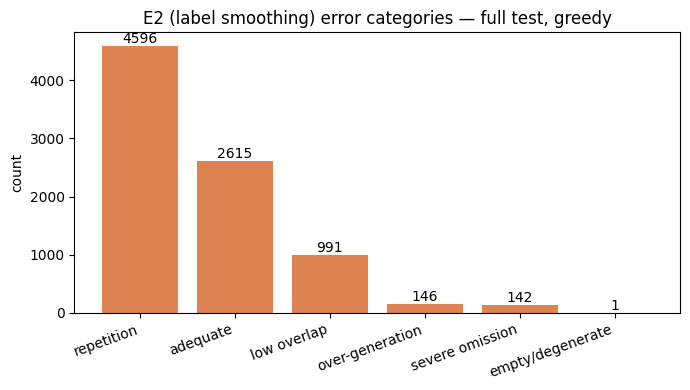

repetition          4596
adequate            2615
low overlap          991
over-generation      146
severe omission      142
empty/degenerate       1
Name: count, dtype: int64

In [17]:
def has_repetition(text):
    toks = text.split()
    if len(toks) < 4: return False
    bg = list(zip(toks, toks[1:]))
    return (len(bg) - len(set(bg)) >= 2) or (len(set(toks)) / len(toks) < 0.5)

def error_category(ref, hyp):
    r, h = ref.split(), hyp.split()
    if not any(c.isalpha() for c in hyp): return "empty/degenerate"
    if has_repetition(hyp): return "repetition"
    if len(h) > 1.8 * max(1, len(r)): return "over-generation"
    if len(h) < 0.5 * len(r): return "severe omission"
    if len(set(h) & set(r)) / max(1, len(set(r))) < 0.2: return "low overlap"
    return "adequate"

cats = [error_category(r, h) for r, h in zip(reference, e2_greedy)]
counts = pd.Series(cats).value_counts()
counts.rename_axis("error_category").reset_index(name="count").to_csv(TABLES / "e2_error_category_counts.csv", index=False)
rep = int(counts.get("repetition", 0)); n = len(e2_greedy)
print(f"E2 greedy repetition: {rep}/{n} = {100*rep/n:.1f}%   (original greedy was 4228/8491 = 49.8%)")
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar_label(ax.bar(counts.index, counts.values, color="#dd8452"))
ax.set_ylabel("count"); ax.set_title("E2 (label smoothing) error categories — full test, greedy")
plt.xticks(rotation=20, ha="right"); fig.tight_layout()
fig.savefig(FIGURES / "e2_error_category_distribution.png", dpi=200); plt.show()
counts

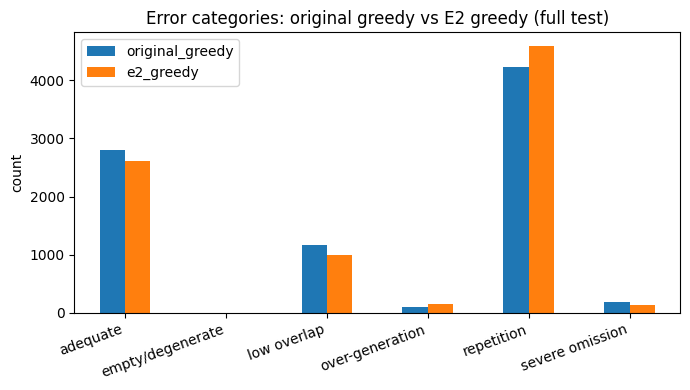

,original_greedy,e2_greedy
adequate,2801,2615
empty/degenerate,1,1
low overlap,1172,991
over-generation,95,146
repetition,4228,4596
severe omission,194,142


In [18]:
# repetition: original greedy vs E2 greedy
orig_rep = pd.read_csv(TABLES / "error_category_counts.csv").set_index("error_category")["count"]
comp = pd.DataFrame({"original_greedy": orig_rep, "e2_greedy": counts}).fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(7, 4)); comp.plot.bar(ax=ax)
ax.set_ylabel("count"); ax.set_title("Error categories: original greedy vs E2 greedy (full test)")
plt.xticks(rotation=20, ha="right"); fig.tight_layout()
fig.savefig(FIGURES / "e2_bleu_chrf_comparison.png", dpi=200); plt.show()
comp

## Qualitative examples
Original greedy vs E2 greedy vs E2 beam, with the heuristic category for the E2 greedy output.

In [19]:
orig = pd.read_csv(EXAMPLES / "full_test_predictions.csv")
orig_greedy = orig["transformer_output"].fillna("").tolist()
qual = pd.DataFrame({"source_ar": src_text, "reference_en": reference,
                     "original_greedy": orig_greedy[:len(reference)],
                     "e2_greedy": e2_greedy, "e2_beam": e2_beam,
                     "e2_error_category": cats})
# pick a spread: some where E2 fixed repetition, some still repeating, plus a few adequate
qual["orig_rep"] = [has_repetition(h) for h in qual["original_greedy"]]
qual["e2_rep"] = [has_repetition(h) for h in qual["e2_greedy"]]
fixed = qual[(qual.orig_rep) & (~qual.e2_rep)].head(6)
still = qual[(qual.orig_rep) & (qual.e2_rep)].head(3)
good = qual[qual.e2_error_category == "adequate"].head(4)
sample = pd.concat([fixed, still, good]).drop_duplicates("source_ar")
sample.drop(columns=["orig_rep", "e2_rep"]).to_csv(EXAMPLES / "e2_qualitative_samples.csv", index=False, encoding="utf-8")
print(f"repetition fixed by E2 (orig repeated, E2 not): {((qual.orig_rep) & (~qual.e2_rep)).sum()} sentences")
display(sample[["reference_en", "original_greedy", "e2_greedy", "e2_error_category"]].head(8))

repetition fixed by E2 (orig repeated, E2 not): 736 sentences


,reference_en,original_greedy,e2_greedy,e2_error_category
7,"so, normally, most people begin by orienting t...","so most people start to get people, and they s...","so, most people start with this task, they're ...",adequate
29,"and with each version, kids get instant feedba...","and what they did was doing is, and what they ...","and yet, they didn't do it. they't work about ...",adequate
61,and what the marshmallow challenge does is it ...,and what we're interested in the national secu...,and what we're doing is that it's a social res...,adequate
77,and everyone in this room has to get into it.,and all of these are inside of them inside of ...,"and all of these people in the box, they're in...",adequate
87,"so i want to get in the machine, and i want to...","so i want to go back to the future, and i want...","so i want to go to go, and go back to the future.",adequate
92,my parents are closing in on 80.,they took two boat two boat two boat.,they've got two-old son.,low overlap
0,"several years ago here at ted, peter skillman ...","the adoption of us have been here, a few years...","in many years ago, we have been using a design...",repetition
1,and the idea's pretty simple: teams of four ha...,"and one of the most famous bricker, one of the...",and one of the most famous examples of the mos...,repetition


## Interpretation — did label smoothing help?

**Mixed, and mostly negative for the main hypothesis.**

- **Repetition was not reduced.** E2 greedy repeats in **4,596 / 8,491 = 54.1%** of outputs vs
  **49.8%** for the original greedy. E2 *fixed* repetition in **736** sentences the original
  looped on, but introduced repetition elsewhere, for a small **net increase**. Label smoothing
  did not solve the degeneracy problem.
- **BLEU slightly lower:** greedy 6.08 (vs 6.22), beam-3 7.37 (vs 7.53). Softening the target
  distribution reduces sharp n-gram precision.
- **chrF++ slightly higher:** greedy 25.06 (vs 24.64), beam-3 25.35 (vs 24.93). Character-level
  overlap improved a little — less over-confident, slightly more faithful subwords.
- The metric disagreement persists: the **dictionary baseline still has the highest chrF++
  (25.65)**; E2 beam-3 is the best *transformer* chrF++ (25.35) but below the baseline. The best
  BLEU overall is still the **original beam-3 (7.53)**.
- Note on loss: E2's validation loss (4.70) is **not** comparable to the original (4.02) because
  label smoothing raises the loss floor; the fair comparison is the BLEU/chrF++ table above.

**Takeaway:** label smoothing trades a little BLEU for a little chrF++ and does **not** fix
repetition — a limited / negative result for the stated goal. **Beam search remains the more
effective lever** so far. Promising next steps: LR warmup (E11) or dropout (E1), then combine
the best regularizer with beam search.

### BLEU / chrF++ comparison figure

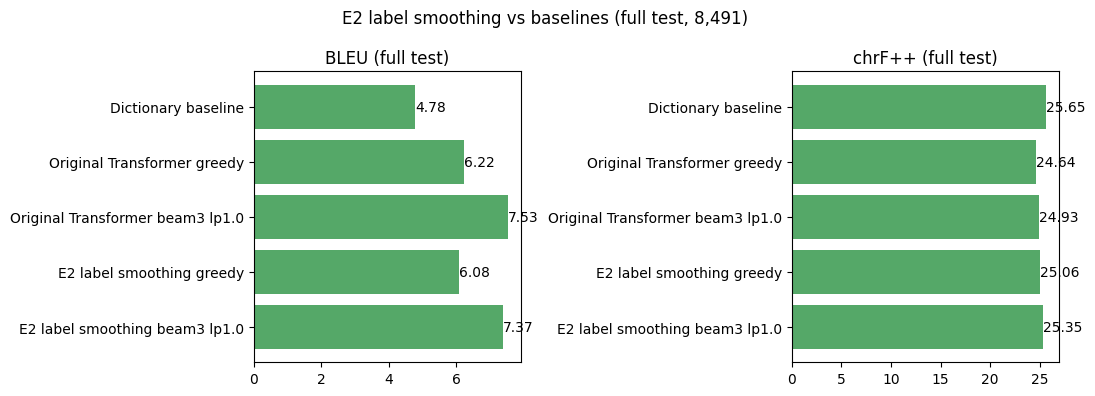

In [1]:
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
import pandas as pd, matplotlib.pyplot as plt
r = pd.read_csv('outputs/tables/e2_eval_results.csv')
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric, title in [(axes[0], 'bleu', 'BLEU (full test)'), (axes[1], 'chrf_pp', 'chrF++ (full test)')]:
    ax.barh(r['model/decoding'], r[metric], color='#55a868')
    ax.bar_label(ax.containers[0], fmt='%.2f'); ax.set_title(title); ax.invert_yaxis()
fig.suptitle('E2 label smoothing vs baselines (full test, 8,491)')
fig.tight_layout(); fig.savefig('outputs/figures/e2_bleu_chrf_comparison.png', dpi=200); plt.show()